# LDA и QDA

Гауссовская модель НБК требует сильное предположение о независимости признаков, отчего все связи между признаками игнорируются. Для непрерывных данных это слишком грубое упрощение.

Решение: Дискриминантный анализ
* Сохраняем генеративный подход
* Отказываемся от предположения о независимости
* Предполагаем многомерное нормальное распределение

### LDA и QDA - генеративный алгоритмы для задач классификации, использующие теорему Байеса, дискриминантный анализ и допущение о многомерном нормальном распределении в своей основе.

### Формулы НБК

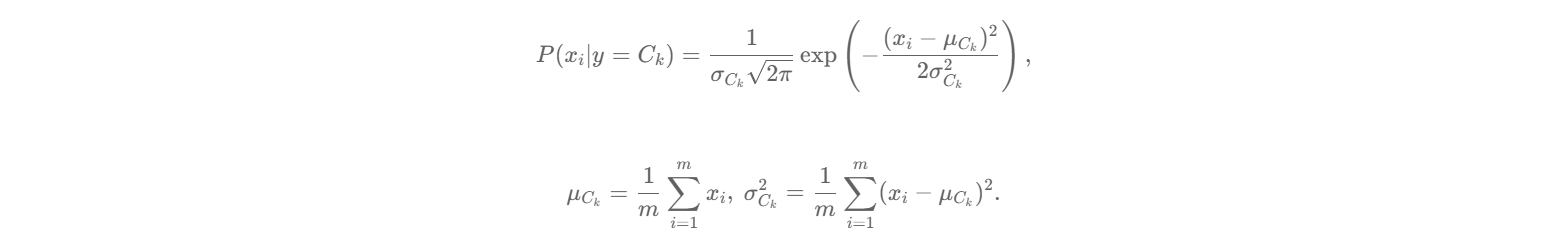

In [ ]:
# np.sum(np.log(self._gaussian_density(x, self.mean[i], self.var[i])))

### Формула многомерного нормального распределения для дискретного анализа


$$P(X|y) = \mathcal{N}(X;\mu_y,\Sigma_y) = \dfrac{1}{(\sqrt{2\pi})^d\sqrt{|\Sigma|}}\exp \left(-\dfrac{(X - \mu_{y})^{\mathrm{T}} \Sigma^{-1}(X - \mu_{y})}{2}\right)$$

где:
* $X$ - вектор признаков одного объекта (длиной d)
* $\mu$ - вектор средних значений признаков по классу (длиной d)
*  Σ - ковариционная матрица размером dxd вместо дисперсии по одному признаку
* |Σ| - определитель матрицы
* d - размерность пространства признаков
* T - операция транспонирования

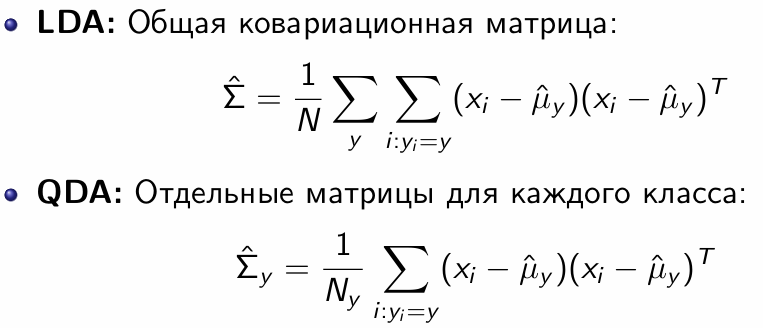

### Вопрос: Что нам дает многомерное нормальное распределение?

1. **Учет корреляций**: Главное, что мы получаем — это возможность моделировать линейные связи между признаками внутри каждого класса. Ковариационная матрица $Σ_k$ говорит нам, например, что если один признак (скажем, рост) больше среднего, то и другой признак (вес), скорее всего, тоже больше среднего. Наивный Байес проигнорировал бы эту связь, а LDA/QDA ее использует.

2. **Появление границ решений**: Подстановка многомерной нормальной плотности в формулу Байеса и взятие логарифма (для упрощения) приводит нас к дискриминантным функциям $δ_k(x)$. Граница между классами a и b возникает там, где значения соответственных функций равны ($δ_a(x)$ == $δ_b(x)$). Природа этой границы (линия или кривая) зависит от того, как мы определяем $Σ_k$.

## Как это работает?

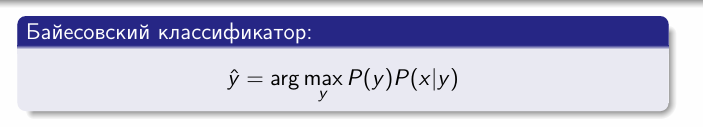

Обозначим:

$$\delta = log(P(y)P(x|y)) = log(P(y)) + log(P(x|y))$$

$$log(P(X|y)) = log(\dfrac{1}{(\sqrt{2\pi})^d\sqrt{|\Sigma|}}\exp \left(-\dfrac{(X - \mu_{y})^{\mathrm{T}} \Sigma^{-1}(X - \mu_{y})}{2}\right)) =  -\dfrac{(X - \mu_{y})^{\mathrm{T}} \Sigma^{-1}(X - \mu_{y})}{2} + const$$

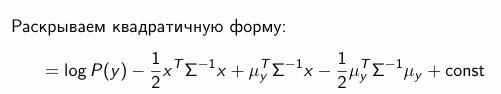

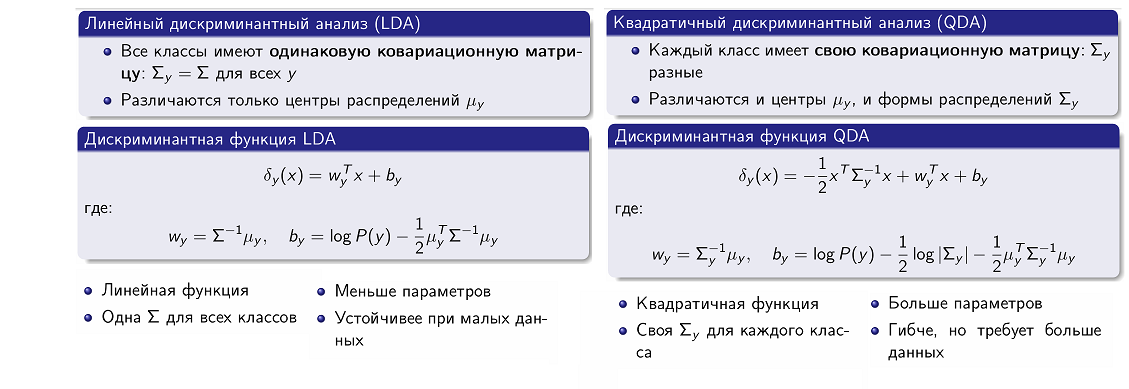

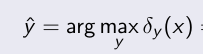

**Квадратичный дискриминантный анализ (QDA):**
QDA — это метод классификации, предполагающий, что каждый класс следует многомерному нормальному распределению со своей собственной матрицей ковариации. Такой гибкий подход означает, что граница принятия решения между классами может быть квадратичной поверхностью. Квадратичная природа позволяет QDA более точно отображать сценарии, где дисперсия внутри классов существенно отличается.

**Линейный дискриминантный анализ (LDA):**
LDA, напротив, предполагает, что каждый класс обычно распределён с равными матрицами ковариации между классами. Это ограничение приводит к линейной границе принятия решения. Хотя это предположение может показаться ограничивающим, оно упрощает модель, обеспечивает надёжность при малых выборках и часто обеспечивает лучшую интерпретируемость.

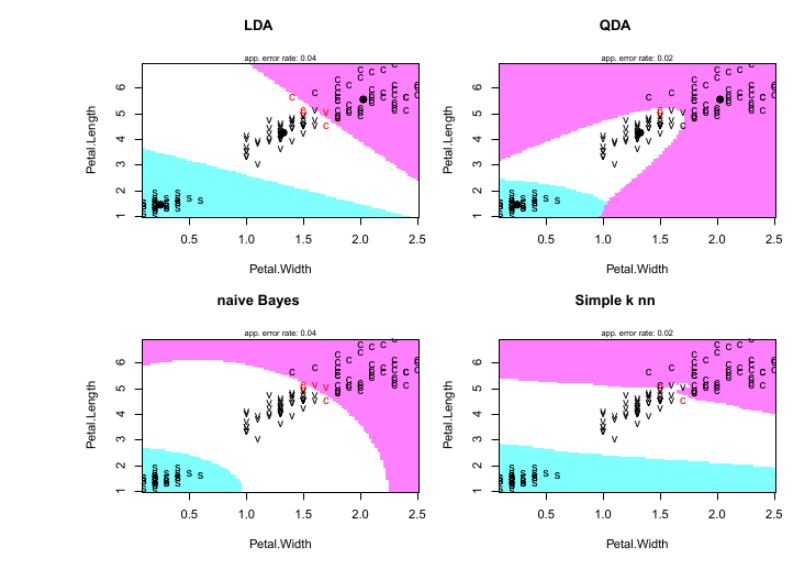

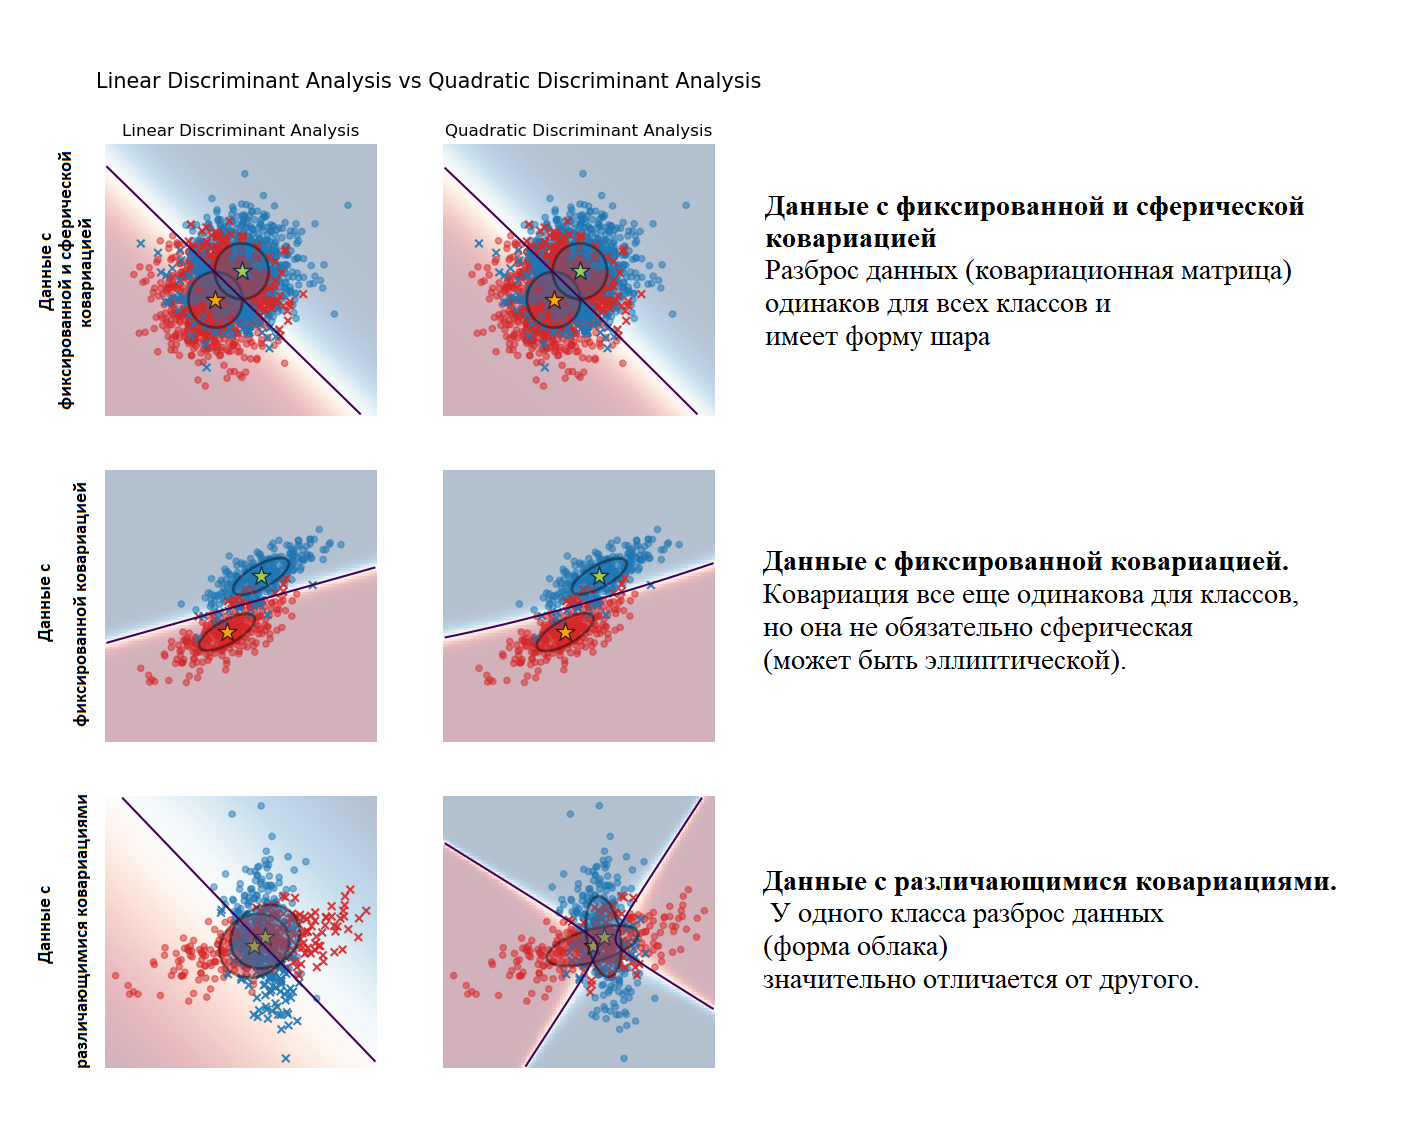

* Из рисунков видно, что нет различий в результатах классификации между LDA и QDA при фиксированной ковариационной матрице；

* Однако при различных ковариационных матрицах существуют очевидные различия в границах классификации LDA и QDA, и LDA больше не может точно делить данные (последние два рисунка)。

## Протестируем работу моделей NBC, LDA, QDA на наборе 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Сгенерируем данные
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, n_classes=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Для всех данных
print("Ковариационная матрица всех признаков:")
print(np.cov(X.T))
print("\n" + "="*50 + "\n")

# Для каждого класса отдельно (для проверки предположений QDA)
for class_label in np.unique(y):
    X_class = X[y == class_label]
    print(f"Ковариационная матрица для класса {class_label}:")
    print(np.cov(X_class.T))
    print(f"Размер класса: {len(X_class)} samples")
    print("-"*30)

Ковариационная матрица всех признаков:
[[1.47491191 0.52078609]
 [0.52078609 1.69583847]]


Ковариационная матрица для класса 0:
[[0.44864108 0.74894598]
 [0.74894598 1.34551217]]
Размер класса: 332 samples
------------------------------
Ковариационная матрица для класса 1:
[[ 0.63926156 -0.66845224]
 [-0.66845224  0.91543734]]
Размер класса: 333 samples
------------------------------
Ковариационная матрица для класса 2:
[[0.98989278 0.24677396]
 [0.24677396 0.2006471 ]]
Размер класса: 335 samples
------------------------------


In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis

gnb = GaussianNB()
gnb.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)


,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


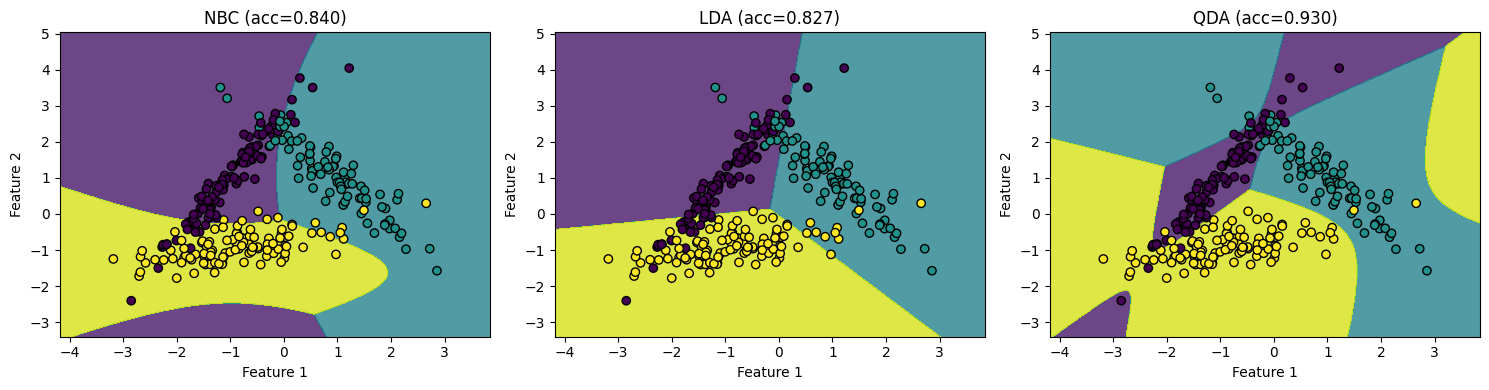

In [10]:
def plot_decision_boundaries(X, y, model, title, subplot_index):
    plt.subplot(subplot_index)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')


plt.figure(figsize=(15, 4))

# Plot decision boundaries for NBC
plot_decision_boundaries(X_test, y_test, gnb, f"NBC (acc={accuracy_score(y_test, gnb.predict(X_test)):.3f})", 131)

# Plot decision boundaries for LDA
plot_decision_boundaries(X_test, y_test, lda, f"LDA (acc={accuracy_score(y_test, lda.predict(X_test)):.3f})", 132)

# Plot decision boundaries for QDA
plot_decision_boundaries(X_test, y_test, qda, f"QDA (acc={accuracy_score(y_test, qda.predict(X_test)):.3f})", 133)

plt.tight_layout()
plt.show()

### Вопрос: Почему QDA лучше всех здесь?

Рассмотрим другой небольшой набор данных, где классы точек можно легко разделить с помощью линий сетки.

In [25]:
from sklearn.datasets import make_blobs
import numpy as np

# Создаем сетку 4x4 (16 классов)
def create_grid_dataset(n_samples_per_class=100, grid_size=4):
    """
    Создает набор данных в виде сетки grid_size x grid_size
    Каждая ячейка сетки - отдельный класс
    """
    n_classes = grid_size * grid_size
    X_list = []
    y_list = []
    
    # Создаем точки для каждой ячейки сетки
    for i in range(grid_size):
        for j in range(grid_size):
            # Центр текущей ячейки
            center_x = i * 2  # Расстояние между центрами по x
            center_y = j * 2  # Расстояние между центрами по y
            
            # Генерируем точки вокруг центра с небольшим разбросом
            X_class, _ = make_blobs(n_samples=n_samples_per_class, 
                                   n_features=2,
                                   centers=[[center_x, center_y]],
                                   cluster_std=0.3,
                                   random_state=42 + i*grid_size + j)
            
            X_list.append(X_class)
            y_list.append(np.full(n_samples_per_class, i*grid_size + j))
    
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    
    return X, y

# Generate synthetic data
X, y = create_grid_dataset(n_samples_per_class=10, grid_size=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [12]:
# Для всех данных
print("Ковариационная матрица всех признаков:")
print(np.cov(X.T))
print("\n" + "="*50 + "\n")

# Для каждого класса отдельно (для проверки предположений QDA)
for class_label in np.unique(y):
    X_class = X[y == class_label]
    print(f"Ковариационная матрица для класса {class_label}:")
    print(np.cov(X_class.T))
    print(f"Размер класса: {len(X_class)} samples")
    print("-"*30)

Ковариационная матрица всех признаков:
[[ 5.12889872e+00 -9.56553576e-04]
 [-9.56553576e-04  5.15855903e+00]]


Ковариационная матрица для класса 0:
[[0.08193121 0.03325102]
 [0.03325102 0.09314711]]
Размер класса: 10 samples
------------------------------
Ковариационная матрица для класса 1:
[[0.10429363 0.0144838 ]
 [0.0144838  0.07115354]]
Размер класса: 10 samples
------------------------------
Ковариационная матрица для класса 2:
[[ 0.12756092 -0.02417588]
 [-0.02417588  0.09211318]]
Размер класса: 10 samples
------------------------------
Ковариационная матрица для класса 3:
[[0.05443998 0.01519798]
 [0.01519798 0.10659991]]
Размер класса: 10 samples
------------------------------
Ковариационная матрица для класса 4:
[[ 0.05849107 -0.03102428]
 [-0.03102428  0.05896657]]
Размер класса: 10 samples
------------------------------
Ковариационная матрица для класса 5:
[[ 0.06784505 -0.00966132]
 [-0.00966132  0.06556753]]
Размер класса: 10 samples
------------------------------
Ковари

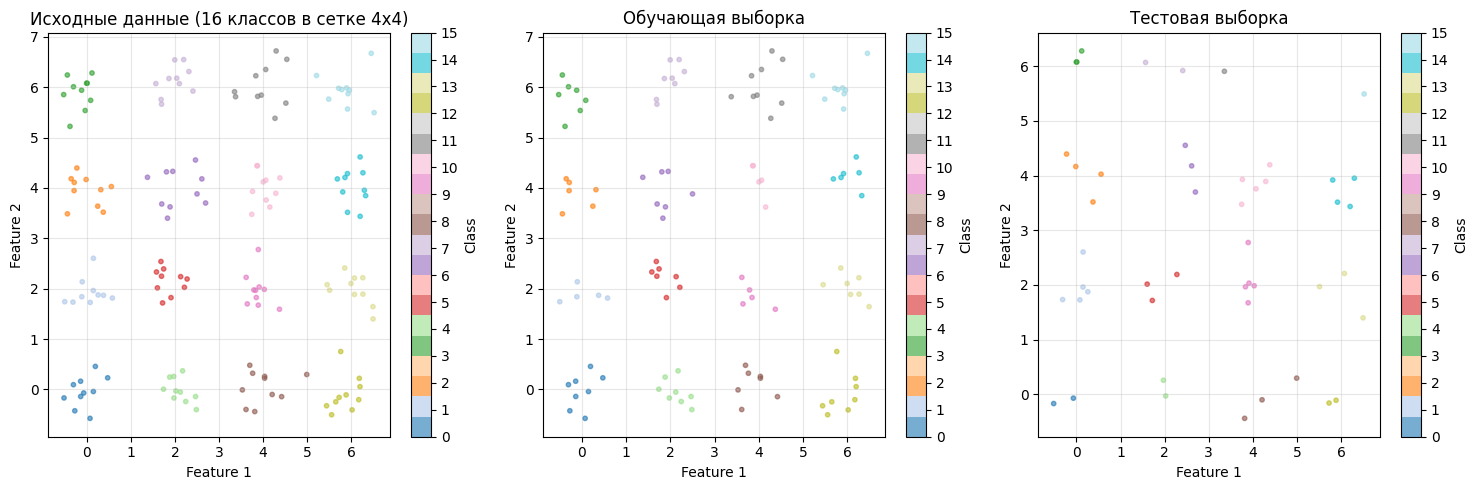

In [521]:
# Визуализируем полученную сетку
plt.figure(figsize=(15, 5))

# Исходные данные
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab20', s=10, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Исходные данные (16 классов в сетке 4x4)')
plt.colorbar(ticks=range(16), label='Class')
plt.grid(True, alpha=0.3)

# Обучающая выборка
plt.subplot(1, 3, 2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='tab20', s=10, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Обучающая выборка')
plt.colorbar(ticks=range(16), label='Class')
plt.grid(True, alpha=0.3)

# Тестовая выборка
plt.subplot(1, 3, 3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='tab20', s=10, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Тестовая выборка')
plt.colorbar(ticks=range(16), label='Class')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [545]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

print(accuracy_score(y_test, gnb.predict(X_test)))
print(accuracy_score(y_test, lda.predict(X_test)))
print(accuracy_score(y_test, qda.predict(X_test)))

0.9583333333333334
0.9791666666666666
0.8958333333333334


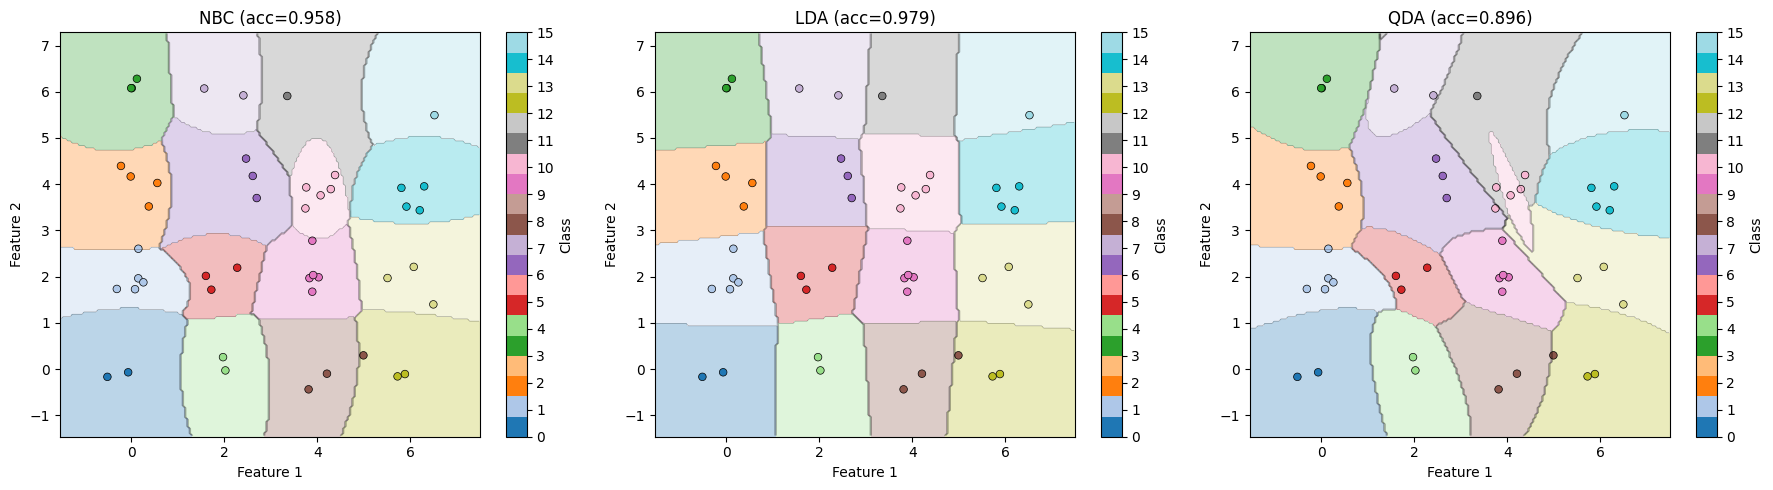

In [543]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def plot_decision_boundaries(X, y, model, title, subplot_index):
    plt.subplot(subplot_index)
    
    # Создаем кастомную цветовую карту для 16 классов
    # Используем tab20 которая имеет 20 различных цветов
    cmap = plt.cm.tab20
    # Для contourf нужно нормализовать цвета
    norm = plt.Normalize(y.min(), y.max())
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Увеличиваем шаг для более быстрой отрисовки (было 0.01, стало 0.05)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Используем pcolormesh вместо contourf для дискретных цветов
    plt.pcolormesh(xx, yy, Z, cmap=cmap, alpha=0.3, shading='auto')
    
    # Добавляем контуры для лучшей видимости границ
    plt.contour(xx, yy, Z, levels=np.arange(-0.5, 16, 1), 
                colors='black', linewidths=0.5, alpha=0.3)
    
    # Отображаем точки данных с теми же цветами
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, 
                         edgecolors='black', linewidth=0.5, s=30)
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    
    # Добавляем цветовую шкалу
    plt.colorbar(scatter, ticks=range(16), label='Class')

# Создаем фигуру
plt.figure(figsize=(18, 5))

# Plot decision boundaries for NBC
plot_decision_boundaries(X_test, y_test, gnb, f"NBC (acc={accuracy_score(y_test, gnb.predict(X_test)):.3f})", 131)

# Plot decision boundaries for LDA
plot_decision_boundaries(X_test, y_test, lda, f"LDA (acc={accuracy_score(y_test, lda.predict(X_test)):.3f})", 132)

# Plot decision boundaries for QDA
plot_decision_boundaries(X_test, y_test, qda, f"QDA (acc={accuracy_score(y_test, qda.predict(X_test)):.3f})", 133)

plt.tight_layout()
plt.show()

### Вопрос: Почему LDA лучше всех здесь?

## Снижение размерности с использованием линейного дискриминантного анализа

LDA может использоваться так же для снижения размерности путем проецирования входных данных на линейное подпространство. Его основная цель — уменьшить количество признаков в наборе данных, сохраняя при этом как можно больше информации, различающей классы.

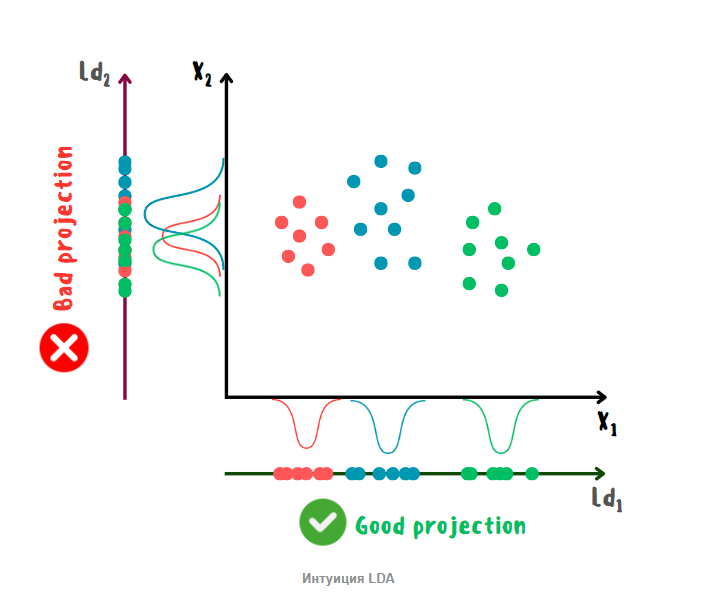

Это реализовано в методе transform. Желаемую размерность можно задать с помощью n_components параметра. Он не влияет на fit и predict методы.

Рассмотрим, как влияет уменьшение размерности может улучшить результаты других моделей. Для этого опять создадим сетку, но на этот раз трехмерную, чтобы мы смогли снизить количество признаков.

In [20]:
from sklearn.datasets import make_blobs
import numpy as np

# Создаем сетку 4x4x4 (64 класса)
def create_grid_dataset(n_samples_per_class=100, grid_size=4):
    """
    Создает набор данных в виде сетки grid_size x grid_size
    Каждая ячейка сетки - отдельный класс
    """
    n_classes = grid_size * grid_size * grid_size
    X_list = []
    y_list = []
    
    # Создаем точки для каждой ячейки сетки
    for i in range(grid_size):
        for j in range(grid_size):
            for k in range(grid_size):
                # Центр текущей ячейки
                center_x = i * 2  # Расстояние между центрами по x
                center_y = j * 4  # Расстояние между центрами по y
                center_z = k * 6  # Расстояние между центрами по z
                
                # Генерируем точки вокруг центра с небольшим разбросом
                X_class, _ = make_blobs(n_samples=n_samples_per_class, 
                                    n_features=3,
                                    centers=[[center_x, center_y, center_z]],
                                    cluster_std=0.3,
                                    random_state=42 + i*grid_size + j + k*2)
                
                X_list.append(X_class)
                y_list.append(np.full(n_samples_per_class, i*grid_size*3//2 + j + k*9//11))
    
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    
    return X, y

# Generate synthetic data
X, y = create_grid_dataset(n_samples_per_class=10, grid_size=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [286]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)


print(accuracy_score(y_test, gnb.predict(X_test)))
print(accuracy_score(y_test, lda.predict(X_test)))
print(accuracy_score(y_test, qda.predict(X_test)))

0.625
0.96875
0.9375


In [287]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda_ = LDA(n_components = 2)
X_train = lda_.fit_transform(X_train, y_train)
X_test = lda_.transform(X_test)

In [288]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

print(accuracy_score(y_test, gnb.predict(X_test)))
print(accuracy_score(y_test, lda.predict(X_test)))
print(accuracy_score(y_test, qda.predict(X_test)))

0.9739583333333334
0.9791666666666666
0.9375


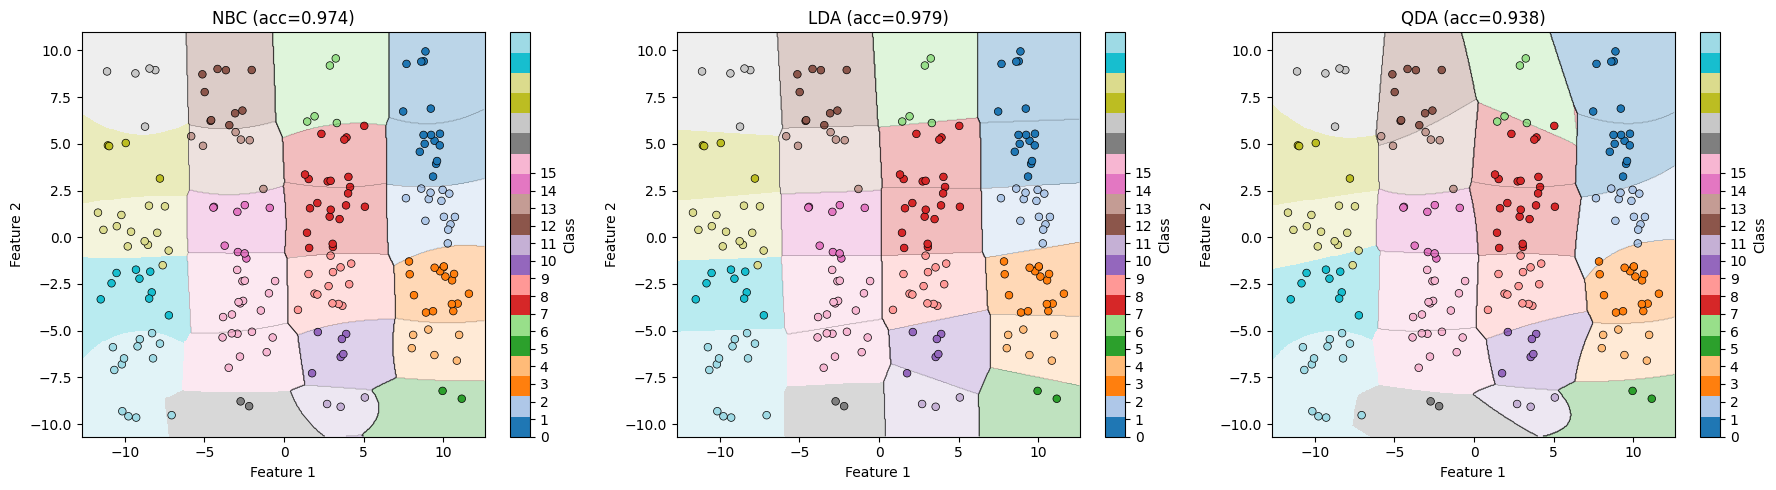

In [289]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def plot_decision_boundaries(X, y, model, title, subplot_index):
    plt.subplot(subplot_index)
    
    # Создаем кастомную цветовую карту для 16 классов
    # Используем tab20 которая имеет 20 различных цветов
    cmap = plt.cm.tab20
    # Для contourf нужно нормализовать цвета
    norm = plt.Normalize(y.min(), y.max())
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Увеличиваем шаг для более быстрой отрисовки (было 0.01, стало 0.05)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Используем pcolormesh вместо contourf для дискретных цветов
    plt.pcolormesh(xx, yy, Z, cmap=cmap, alpha=0.3, shading='auto')
    
    # Добавляем контуры для лучшей видимости границ
    plt.contour(xx, yy, Z, levels=np.arange(-0.5, 16, 1), 
                colors='black', linewidths=0.5, alpha=0.3)
    
    # Отображаем точки данных с теми же цветами
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, 
                         edgecolors='black', linewidth=0.5, s=30)
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    
    # Добавляем цветовую шкалу
    plt.colorbar(scatter, ticks=range(16), label='Class')

# Создаем фигуру
plt.figure(figsize=(18, 5))

# Plot decision boundaries for NBC
plot_decision_boundaries(X_test, y_test, gnb, f"NBC (acc={accuracy_score(y_test, gnb.predict(X_test)):.3f})", 131)

# Plot decision boundaries for LDA
plot_decision_boundaries(X_test, y_test, lda, f"LDA (acc={accuracy_score(y_test, lda.predict(X_test)):.3f})", 132)

# Plot decision boundaries for QDA
plot_decision_boundaries(X_test, y_test, qda, f"QDA (acc={accuracy_score(y_test, qda.predict(X_test)):.3f})", 133)

plt.tight_layout()
plt.show()

### Что произошло?

Мы видим, что:

* GaussianNB существенно выиграл от LDA-преобразования, так как в новом пространстве признаки стали более независимыми и нормально распределенными

* LDA стабильно показывал высокие результаты в обоих случаях, что ожидаемо, так как он оптимизирует разделимость классов

* QDA сохранил свою эффективность, что говорит о том, что ковариационные матрицы классов различны

## Задание: Реализуйте класс LDA с нуля


При решении запрещено использовать дискриминант Фишера.

Следите за размерностями.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh as sp_eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

In [ ]:
import numpy as np # при отправке не забудьте добавить все необходимые библиотеки

class LDA:
    def __init__(self):
        pass

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_, cls_counts = np.unique(y, return_counts=True)
        n_classes = len(self.classes_)
        
        # Априорные вероятности классов
        self.priors_ = ... # TODO P(y)
        
        # Средние векторы для каждого класса
        self.means_ = ... # TODO mu
        
        # Ковариационные матрицы для каждого класса
        self.covariance_ = 0.0 # Σ 
        self.weights_ = []  # w_y
        
        for i, cls in enumerate(self.classes_):
            X_cls = X[y == cls]

            # Вычитаем среднее класса
            X_centered = ... # TODO (m, d), где m - количество строк, а d - признаков. Смотреть формулу Σ

            # Добавляем к общей ковариации произведение центрированных данных
            self.covariance_ += ... # TODO (d, m) @ (m, d) = (d, d) - то, что нужно. Произведение - это внутренняя сумма, covariance_ - внешняя

        # Нормализация на общее количество образцов
        self.covariance_ /= ... # TODO
        
        # Обратная ковариационная матрица
        self.precision_ = np.linalg.inv(self.covariance_) # (d, d) - размер не меняется
        
        # Веса для линейной дискриминантной функции
        self.weights_ = ... # TODO w: (d, d) @ (d, K) = (d, K), где K - количество классов
        
        # Свободные члены
        quad = ... # TODO (K, d) @ (d, d) @ (d, K) = (K, K)
        self.biases_ = np.log(self.priors_) - 0.5 * np.diag(quad) # b: (K,) - объяснение, почему нужна именно диагональ, ниже
        
        return self

    def _compute_discriminant_function(self, X):
        """Вычисляет дискриминантную функцию для всех классов"""
        discriminant = ... # TODO delta: (N, d) @ (d, K) + (K) = (N, K) + (K,) - происходит broadcasting: к каждой строке матрицы прибавляется вектор biases
        return discriminant

    def predict(self, X):
        """Предсказывает метки классов"""
        discriminant = self._compute_discriminant_function(X)
        return self.classes_[np.argmax(discriminant, axis=1)]

Для самопроверки:

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

my_lda = LDA()
my_lda.fit(X_train, y_train)

print(accuracy_score(y_test, lda.predict(X_test)))
print(accuracy_score(y_test, my_lda.predict(X_test)))
print((my_lda.predict(X_test) != lda.predict(X_test)).sum())

0.9791666666666666
0.9791666666666666


**Почему нам нужна только диагональ при подсчете biases?**

Потому что для свободного члена bias для класса k будет следующая формула:


In [ ]:
# bias[k] = log(priors[k]) - 0.5 * (means[k].T @ precision @ means[k])

Обратите внимание: здесь используется means[k] для одного и того же класса k дважды. Это соответствует диагональным элементам матрицы.

## Задание: Реализуйте класс QDA с нуля

In [ ]:
import numpy as np # при отправке не забудьте добавить все необходимые библиотеки

class QDA:
    def __init__(self):
        pass

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_, cls_counts = np.unique(y, return_counts=True)
        n_classes = len(self.classes_)

        # Априорные вероятности классов
        self.priors_ = ... # TODO P(y)
        
        # Средние векторы для каждого класса
        self.means_ = ... # TODO mu
        
        # Ковариационные матрицы для каждого класса
        self.covariances_ = []
        self.precisions_ = []  # Обратные ковариационные матрицы
        self.det_covariances_ = []  # Детерминанты ковариационных матриц для b_y
        self.weights_ = []  # w_y
        
        for i, cls in enumerate(self.classes_):
            X_cls = X[y == cls]
            # Вычитаем среднее класса
            X_centered = ... # TODO (m, d), где m - количество строк, а d - признаков. Смотреть формулу Σ
            # Добавляем к общей ковариации
            cov = ... # TODO (d, m) @ (m, d) = (d, d) - то, что нужно. Произведение - это внутренняя сумма, covariance_ - внешняя
            # Нормализация на общее количество образцов
            cov /= ... # TODO

            self.covariances_.append(cov)
            
            # Обратная ковариационная матрица
            precision = np.linalg.inv(cov) # (d, d)
            self.precisions_.append(precision)

            # Детерминант ковариационной матрицы
            det = np.linalg.det(cov) # число
            self.det_covariances_.append(det)

            # Веса для линейной дискриминантной функции       
            weight = ... # TODO w: (d, d) @ (d,) = (d,)
            self.weights_.append(weight)
        
        # Для удобства дальнейшей работы
        self.covariances_ = np.array(self.covariances_)
        self.precisions_ = np.array(self.precisions_)
        self.det_covariances_ = np.array(self.det_covariances_)
        self.weights_ = np.array(self.weights_)
        
        return self

    def _compute_discriminant_function(self, X):
        """Вычисляет дискриминантную функцию для всех классов"""
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        discriminant = np.zeros((n_samples, n_classes))
        
        for i in range(n_classes):
            # Член -1/2 * x^T Σ^{-1} x
            quad = ... # TODO ((N, d) @ (d, d)) * (N, d) - поэлементное умножение = (N, d)
            quad_term = -0.5 * np.sum(quad, axis=1) # (N,) - объяснение почему нужна именно сумма ниже
            
            # Член w^T x
            linear_term = ... # TODO (N, d) @ (d,) = (N,)
            
            # Свободный член b_y
            bias = ... # TODO b число, которое прибавляется к каждому значения вектора
            
            discriminant[:, i] = quad_term + linear_term + bias # вероятность каждого класса по отдельности для всех N объектов
        
        return discriminant

    def predict(self, X):
        """Предсказывает метки классов"""
        discriminant = self._compute_discriminant_function(X)  # (N, K)
        return self.classes_[np.argmax(discriminant, axis=1)]

Для самопроверки:

In [ ]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

my_qda = QDA()
my_qda.fit(X_train, y_train)

print(accuracy_score(y_test, qda.predict(X_test)))
print(accuracy_score(y_test, my_qda.predict(X_test)))
print((my_lda.predict(X_test) != lda.predict(X_test)).sum())

0.8958333333333334
0.8958333333333334


**Почему нам нужна сумма при подсчете квадратичного слагаемого?**

Квадратичный член в дискриминантной функции QDA:

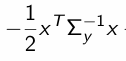


Для одного объекта $\mathbf{x}$ (вектор размерности $d$):

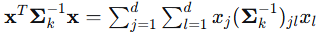

В векторной форме это можно записать как:

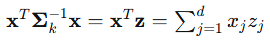

Отсюда и сумма